## Estimation of the loan-default amount

### 1.Data cleaning

In [2]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series
path='F:/Data Project/Kaggle/'
def_data=pd.read_csv(path+'Loan_default.csv',sep=',')
def_data.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
print(def_data.columns.tolist())
print(def_data.shape)          
print(def_data.dtypes)         
print(def_data.isnull().sum()) 
print(def_data['Default'].value_counts())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']
(255347, 18)
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStat

### 2.EDA & Visualisation

In [4]:
def_data.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


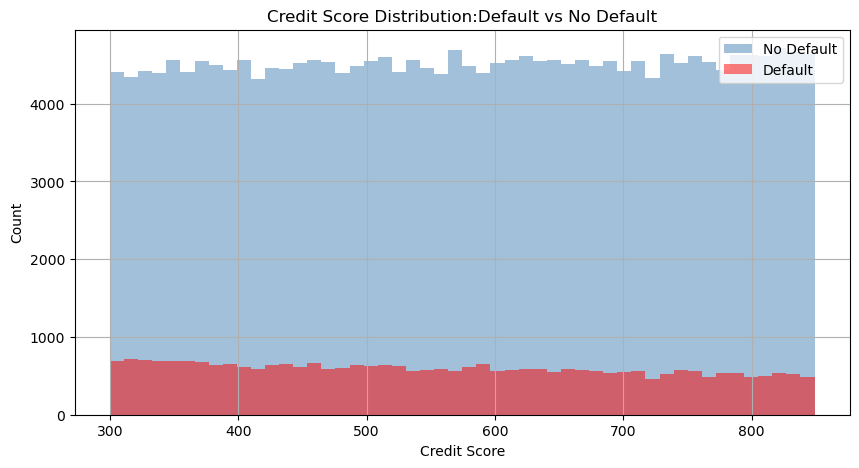

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
def_data[def_data['Default']==0]['CreditScore'].hist(alpha=0.5,label='No Default', bins=50, color='steelblue')
def_data[def_data['Default']==1]['CreditScore'].hist(alpha=0.5,label='Default',bins=50,color='red')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.title('Credit Score Distribution:Default vs No Default')
plt.legend()
plt.show()

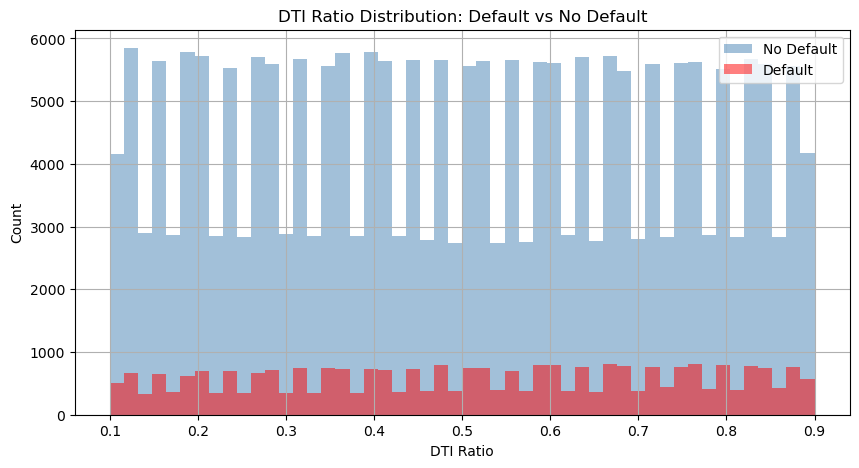

In [6]:
plt.figure(figsize=(10, 5))
def_data[def_data['Default']==0]['DTIRatio'].hist(alpha=0.5, label='No Default', bins=50, color='steelblue')
def_data[def_data['Default']==1]['DTIRatio'].hist(alpha=0.5, label='Default', bins=50, color='red')
plt.xlabel('DTI Ratio')
plt.ylabel('Count')
plt.title('DTI Ratio Distribution: Default vs No Default')
plt.legend()
plt.show()

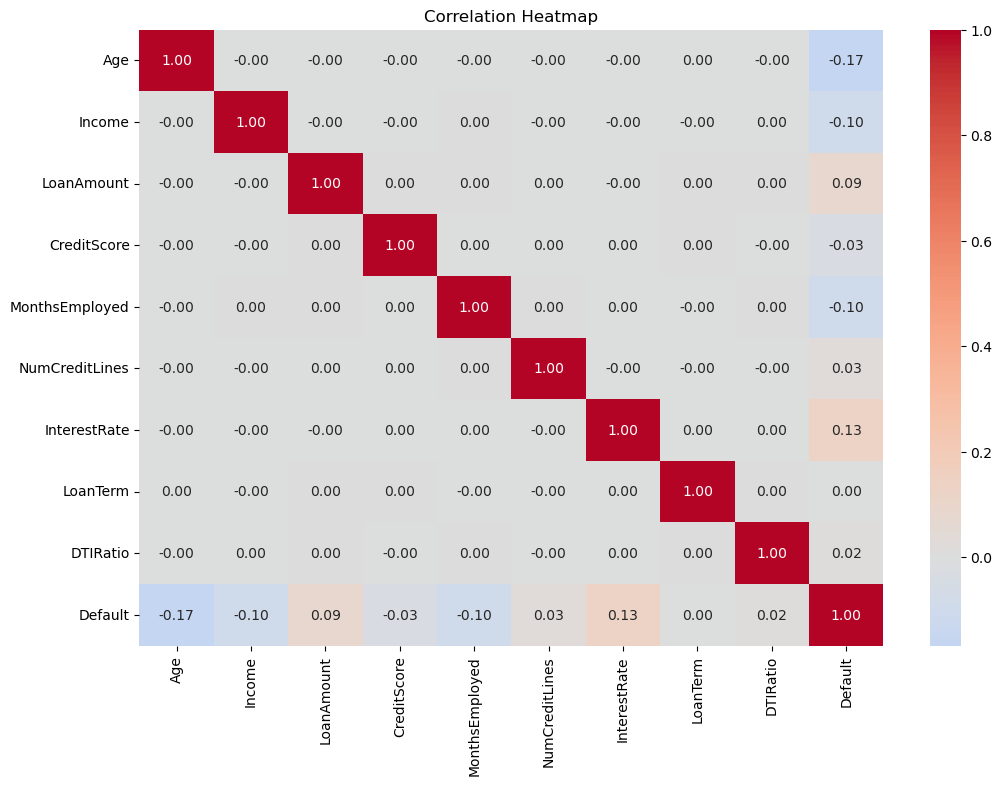

In [7]:
import seaborn as sns

plt.figure(figsize=(12,8))
corr=def_data.select_dtypes(include='number').corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('Correlation Heatmap')
plt.show()

#### Seperate Data

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

cat_cols=['Education','EmploymentType','MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']

le=LabelEncoder()
for col in cat_cols:
    def_data[col]=le.fit_transform(def_data[col])

X=def_data.drop(['LoanID','Default'],axis=1)
y=def_data['Default']

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)

(204277, 16) (51070, 16)


### 3.Logistic Regression Model:

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr=LogisticRegression(max_iter=3000, random_state=42)
lr.fit(X_train,y_train)

y_pred_lr=lr.predict(X_test)
y_prob_lr=lr.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.62      0.03      0.07      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.86      0.89      0.84     51070

AUC Score: 0.7484


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Randomo Forest Model:

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.60      0.05      0.09      5931

    accuracy                           0.89     51070
   macro avg       0.74      0.52      0.51     51070
weighted avg       0.85      0.89      0.84     51070

AUC Score: 0.7347


### xgboost:

In [18]:
!pip install xgboost
from xgboost import XGBClassifier

# 计算不平衡比例
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"不平衡比例: {ratio:.1f}")

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=ratio,  # 告诉模型违约者更重要
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 11.2 MB/s eta 0:00:09
   - -------------------------------------- 4.7/101.7 MB 11.9 MB/s eta 0:00:09
   -- ------------------------------------- 7.3/101.7 MB 12.2 MB/s eta 0:00:08
   --- ------------------------------------ 9.7/101.7 MB 12.1 MB/s eta 0:00:08
   ---- ----------------------------------- 12.6/101.7 MB 12.4 MB/s eta 0:00:08
   ----- ---------------------------------- 14.9/101.7 MB 12.3 MB/s eta 0:00:08
   ------- -------------------------------- 17.8/101.7 MB 12.4 MB/s eta 0:00:07
   ------- -------------------------------- 19.7/101.7 MB 12.4 MB/s eta 0:00:07
   -------- ------------------------------- 21.2/101.7 MB 11.5 MB/s eta 0:00:08
   -------- ------------------------------- 22.8/101.7 MB 11.1 MB/s eta 0:00:08
   --------- ------------------------------ 24.1/101.7 MB 10.7 MB/s eta 0:00:08
   ---------- ----------------------------- 25.4/101.

### 4.SHAP Interpretability Analysis


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



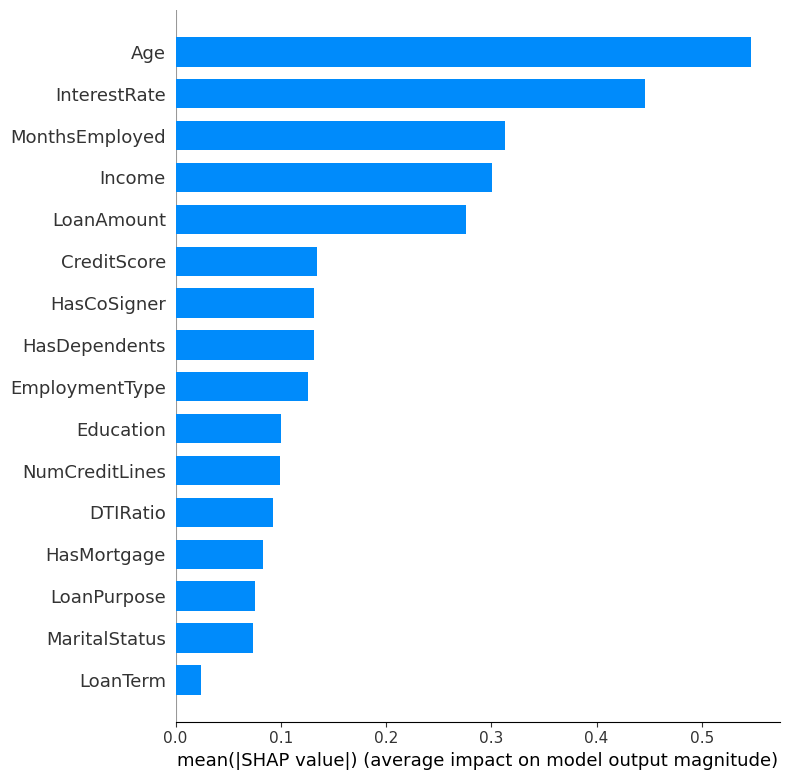

In [19]:
!pip install shap

import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:1000])

shap.summary_plot(shap_values, X_test[:1000], plot_type='bar')